# Plot Transform
A notebook to show the impact of a given transform on an image.

In [2]:
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from torchvision.transforms import v2

from vnn import datasets
from vnn.pwl import generate_samples
from vnn.visualization import plot_samples

## Define dataset and image

In [3]:
dataset = datasets.GTSRB(size=512)

i = 34
num_samples = 10
padding_value = 0  # "BORDER_REPLICATE"
img = dataset[i][0].numpy()

h = w = 512
img_path = Path("interstate.png")
img = Image.open(img_path).convert("RGB")
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.Resize((h, w)),
        v2.ToDtype(torch.float32, scale=True),
    ]
)
img = transform(img).numpy()

## Define transform

In [4]:
from vnn.transforms import (
    TransformWithBounds,
    # Non-affine
    HomographyRoll,
    HomographyPitch,
    HomographyYaw,
    HomographyX,
    HomographyY,
    HomographyZ,
    # Affine
    Scale,
    ShearX,
    TranslateX,
    TranslateY,
)

h = img.shape[1]
w = img.shape[2]
print(w, h)

xc = w / 2
yc = h / 2
focal_length_px = w / 2  # Approximate focal length
z = -5

lower = 0
upper = np.deg2rad(15)
tfwb = TransformWithBounds(
    HomographyYaw(f=focal_length_px, xc=xc, yc=yc), lower_bound=lower, upper_bound=upper
)
tfwb = TransformWithBounds(
    HomographyPitch(f=focal_length_px, xc=xc, yc=yc),
    lower_bound=lower,
    upper_bound=upper,
)
tfwb = TransformWithBounds(
    HomographyRoll(xc=xc, yc=yc), lower_bound=lower, upper_bound=upper
)

lower = 0
upper = 2
tfwb = TransformWithBounds(
    HomographyX(f=focal_length_px, xc=xc, yc=yc, z=z),
    lower_bound=lower,
    upper_bound=upper,
)
tfwb = TransformWithBounds(
    HomographyY(f=focal_length_px, xc=xc, yc=yc, z=z),
    lower_bound=lower,
    upper_bound=upper,
)
tfwb = TransformWithBounds(
    HomographyZ(f=focal_length_px, xc=xc, yc=yc, z=z),
    lower_bound=lower,
    upper_bound=upper,
)
tfwb = TransformWithBounds(Scale(x0=xc, y0=yc), lower_bound=1, upper_bound=2)
tfwb = TransformWithBounds(TranslateX(), lower_bound=-100, upper_bound=100)
tfwb = TransformWithBounds(TranslateY(), lower_bound=-100, upper_bound=100)
tfwb = TransformWithBounds(ShearX(y0=yc), lower_bound=-0.5, upper_bound=0.5)

512 512


## Visualize transform

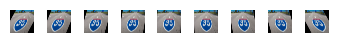

In [5]:
samples, params = generate_samples(
    img,
    tfwb.transform,
    lower_bound=tfwb.lower_bound,
    upper_bound=tfwb.upper_bound,
    num_samples=num_samples,
    padding=padding_value,
)
fig = plot_samples(samples)

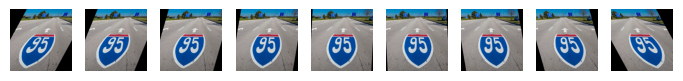

In [6]:
import matplotlib.pyplot as plt
import numpy as np

from vnn.visualization import setup_latex, TEXTWIDTH_PT, get_figure_size

num_images = 9

setup_latex()
fig_size = get_figure_size(width_pt=2 * TEXTWIDTH_PT)
fig = plt.figure(figsize=fig_size)

# Pick `num_images` samples to plot
idx_images = np.linspace(0, len(samples) - 1, num_images, dtype=int)

# Keep color scale constant for each sample
vmin = samples[0].min()
vmax = samples[0].max()

for idx_grid, idx_image in enumerate(idx_images):
    plt.subplot(1, num_images, idx_grid + 1)
    plt.imshow(samples[idx_image].transpose(1, 2, 0), cmap="gray", vmin=vmin, vmax=vmax)
    plt.axis("off")

plt.tight_layout()
name = tfwb.transform.__class__.__name__
fig.savefig(f"{name}.pdf")